# Wstęp
Zadanie 6 stanowi wprowadzenie w tematykę *data augmentation*. Ze względu na złożonośc modeli głębokich, zwykle wymagają one bardzo dużych zbiorów danych do dobrego wyuczenia. Jednym ze sposobów na skalowanie ilości dostępnych danych są metody tzw. augmentacji - przekształcenia na danych które mamy, aby utworzyć nowe przykłady o znanych etykietach. Pod koniec zadania wprowadzona jest również koncepcja *skip connections*, będących istotnym elementem współczesnych architektur konwolucyjnych i nie tylko.

# Cel ćwiczenia

Celem ćwiczenia jest zapoznanie się z

*    koncepcją augmentacji danych
*    implementacją metod augmentacji danych obrazowych w torch.transforms
*    koncepcją augmentacji niezależnej od dziedziny
*    modelami sieci głębokich ze skip connections

# Augmentacja danych obrazowych

W pierwszej kolejności zapoznajmy się z funkcjonalnością augmentacji danych obrazowych. W pytorch funkcjonalność ta realizowana jest przez transformacje wykonywane na obrazach przez `torchvision.transforms`.

Transformacje które typowo wykorzystuje się w augmentacji to standardowe przekształcenia afiniczne obrazu - rotacje, dobicia, skalowanie. Oczywiście, pownniśmy dobierać transformacje z takich, po których rzeczywiście oczekujemy inwariancji - przekształcony obraz będziemy podawać do sieci z tą samą etykietą. Przykładowo, na zbiorze odręcznie pisanych cyfr MNIST ograniczymy zakres obrotów czy wykorzystanie odbicia w osi poziomej, jako że niechcemy pomylić 5 z 2 czy 6 z 9.

Zapoznaj się z dokumentacją transforms tutaj:

https://pytorch.org/vision/stable/transforms.html

Kod poniżej wczytuje CIFAR 10 i pokazuje wyniki przykładowej augmentacji - losowej rotacji o kąt -30 do 30 stopni.

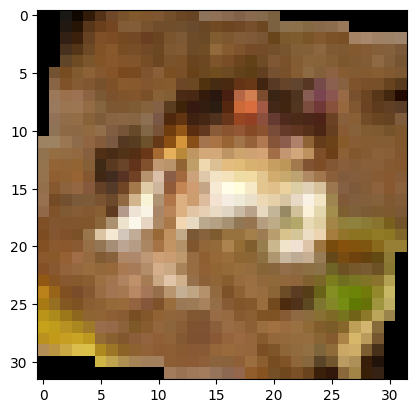

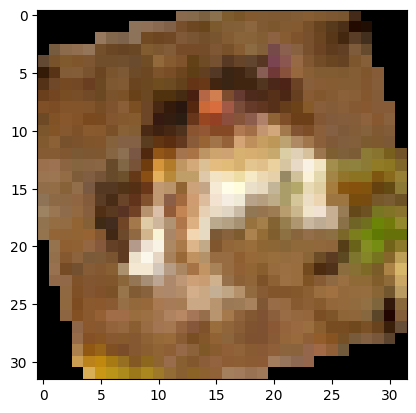

In [9]:
import torch
import torchvision
import torchvision.transforms as transforms
from matplotlib import pyplot as plt


transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
img, label = train_ds[0]

plt.imshow(img.permute(1,2,0))
plt.show()

img, label = train_ds[0]

plt.imshow(img.permute(1,2,0))
plt.show()

Widzimy tutaj kolejny potencjalny problem z augmentacjami: ze względu na konieczność utrzymania stałego kształtu wejścia, augmentacje mogą wprowadzać artefakty takie jak czarne fragmenty na krawędziach obrazu czy aliasing wynikający z niskiej rozdzielczości.

Poniżej kod pomocniczy z laboratorium 3, można zastąpić go własną implementacją pętli uczącej uwzględniającej ulepszenia wykonane na laboratoriach 4 i 5. W zadaniach poniżej wystarczy porównać końcowy wynik uczenia, nie jest wymagane wyrysowywanie pełnych krzywych w tensorboard niemniej mogą one pomóc w analizie otrzymanych wyników.

In [10]:
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from typing import Tuple
from tqdm.notebook import tqdm

transform = torchvision.transforms.ToTensor()

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
test_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, train=False, download=True)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=32, pin_memory=True)

def count_correct(
    y_pred: torch.Tensor, y_true: torch.Tensor
) -> torch.Tensor:
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().sum()

def validate(
    model: nn.Module,
    loss_fn: torch.nn.CrossEntropyLoss,
    dataloader: DataLoader
) -> Tuple[torch.Tensor, torch.Tensor]:
    loss = 0
    correct = 0
    all = 0
    for X_batch, y_batch in dataloader:
        y_pred = model(X_batch)
        all += len(y_pred)
        loss += loss_fn(y_pred, y_batch).sum()
        correct += count_correct(y_pred, y_batch)
    return loss / all, correct / all

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: str = True
):
  for epoch in range(epochs):
      for X_batch, y_batch in tqdm(train_dl):
          y_pred = model(X_batch)
          loss = loss_fn(y_pred, y_batch)

          loss.backward()
          optimiser.step()
          optimiser.zero_grad()

      if print_metrics:
          model.eval()
          with torch.no_grad():
              train_loss, train_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=train_dl
              )
              val_loss, val_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=val_dl
              )
              print(
                  f"Epoch {epoch}: "
                  f"train loss = {train_loss:.3f} (acc: {train_acc:.3f}), "
                  f"validation loss = {val_loss:.3f} (acc: {val_acc:.3f})"
              )

# Zadanie 1

Wykorzystując klasę ThreeLayerCNN z `channels=32`, spróbuj dobrać augmentacje danych tak aby poprawić wyniki względem jej braku na zbiorze CIFAR10.

In [11]:
class ThreeLayerCNN(torch.nn.Module):
  def __init__(self, channels: int, labels: int = 10):
    super().__init__()
    self.model = torch.nn.Sequential()
    self.model.add_module("in_conv",
                          torch.nn.Conv2d(3, channels, 1))
    self.model.add_module("relu_1", torch.nn.ReLU())
    self.model.add_module("conv_1",
                          torch.nn.Conv2d(channels, channels, 3, padding=1))
    self.model.add_module("relu_2", torch.nn.ReLU())
    self.model.add_module("max_pool_1", torch.nn.MaxPool2d(2))
    self.model.add_module("conv_2",
                          torch.nn.Conv2d(channels, channels, 3, padding=1))
    self.model.add_module("relu_3", torch.nn.ReLU())
    self.model.add_module("max_pool_2", torch.nn.MaxPool2d(2))
    self.model.add_module("flatten", torch.nn.Flatten())
    self.model.add_module("linear", torch.nn.Linear( channels * 8 * 8 , 10)) #uzupełnij

  def forward(self, x):
    return self.model(x)

Zaprogramuj eksperyment tak, aby w pętli sprawdzać kolejne potencjalne wersje potoku przetwarzania (różniące się tutaj tylko augmentacją), a na końcu wybrać najlepszą - tak aby możliwe było powtórzenie całego eksperymentu uzasadniającego wybór! Transformacja z augmentacją ma być wywoływana tylko na danych treningowych.

Spróbuj znaleźć również przykład augmentacji pogarszającej wynik w stosunku do bazowego otrzymanego bez augmentacji. Wykorzystaj uczenie na 50 epok i optymalizator Adam z domyślnymi parametrami, bez regularyzacji.

Eksperymenty:   0%|          | 0/4 [00:00<?, ?it/s]


Eksperyment: baseline


baseline:   0%|          | 0/20 [00:00<?, ?it/s]


Eksperyment: good_flip_crop


good_flip_crop:   0%|          | 0/20 [00:00<?, ?it/s]


Eksperyment: good_color_jitter


good_color_jitter:   0%|          | 0/20 [00:00<?, ?it/s]


Eksperyment: bad_aggressive


bad_aggressive:   0%|          | 0/20 [00:00<?, ?it/s]

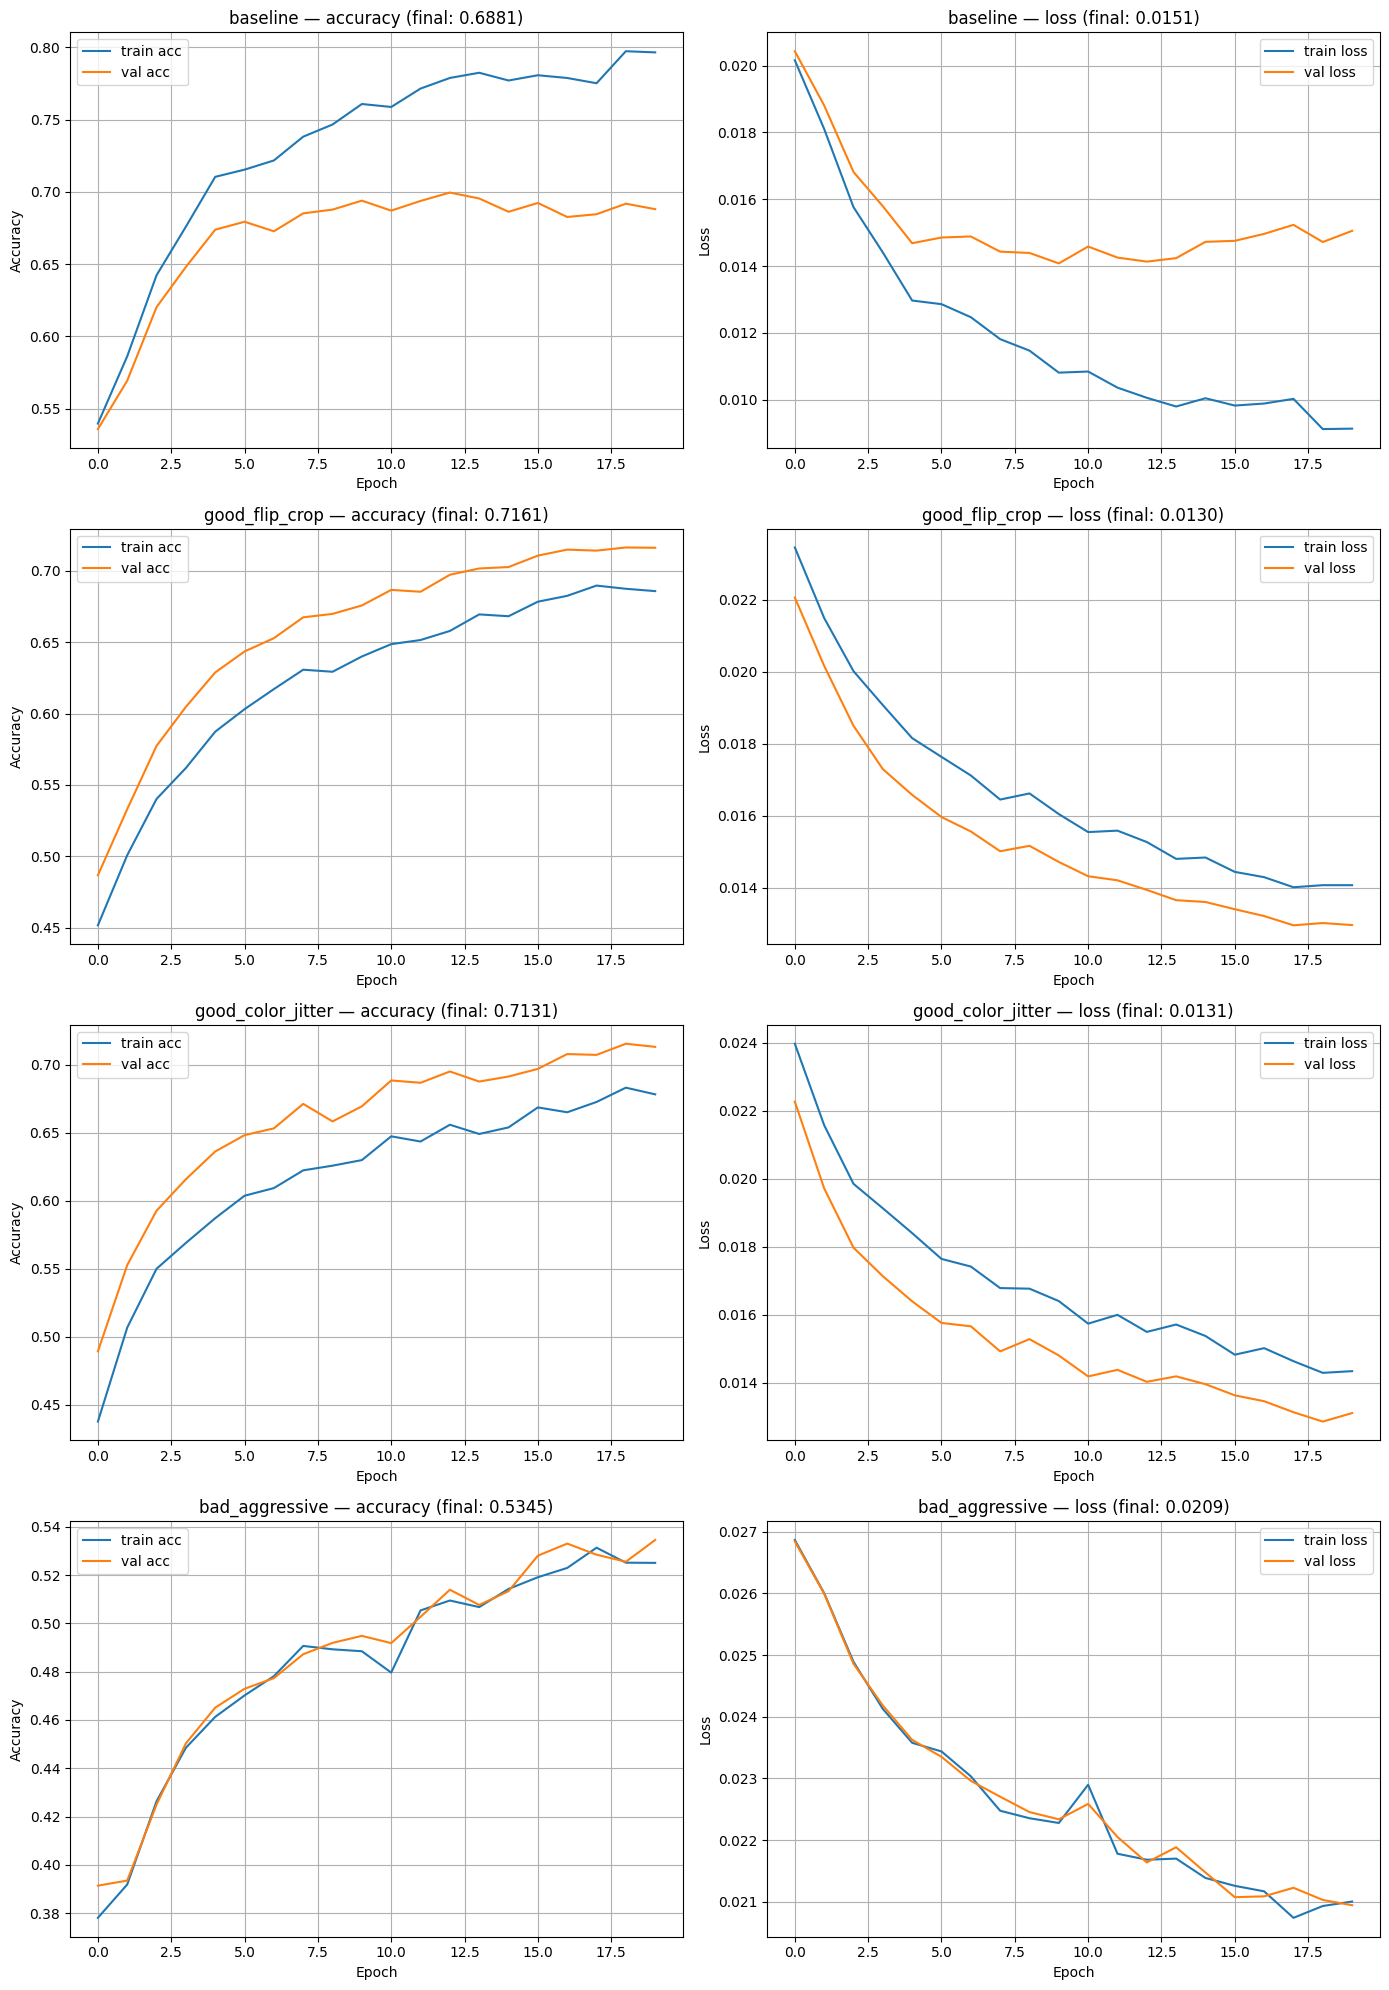


PODSUMOWANIE:
  good_flip_crop            acc = 0.7161  loss = 0.0130  (+0.0280 acc, -0.0021 loss vs baseline)
  good_color_jitter         acc = 0.7131  loss = 0.0131  (+0.0250 acc, -0.0019 loss vs baseline)
  baseline                  acc = 0.6881  loss = 0.0151
  bad_aggressive            acc = 0.5345  loss = 0.0209  (-0.1536 acc, +0.0059 loss vs baseline)


In [12]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

SEED = 42
EPOCHS = 20
CHANNELS = 32

to_tensor = transforms.ToTensor()

augmentations = {
    "baseline": transforms.Compose([
        transforms.ToTensor()
    ]),
    "good_flip_crop": transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor()
    ]),
    "good_color_jitter": transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor()
    ]),
    "bad_aggressive": transforms.Compose([
        transforms.RandomRotation(90),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor()
    ]),
}

test_ds = torchvision.datasets.CIFAR10("cifar_root", transform=to_tensor, train=False, download=True)
test_dl = DataLoader(test_ds, batch_size=64, pin_memory=True)

results = {}
histories = {}

for name, train_transform in tqdm(augmentations.items(), desc="Eksperymenty"):
    print(f"\n{'='*50}\nEksperyment: {name}\n{'='*50}")

    torch.manual_seed(SEED)

    train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=train_transform, download=True)
    train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, pin_memory=True)

    model = ThreeLayerCNN(channels=CHANNELS, labels=10)
    optimiser = optim.Adam(model.parameters())
    loss_fn = nn.CrossEntropyLoss()

    train_accs, val_accs, train_losses, val_losses = [], [], [], []

    for epoch in tqdm(range(EPOCHS), desc=name, leave=False):
        model.train()
        for X_batch, y_batch in train_dl:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimiser.step()
            optimiser.zero_grad()

        model.eval()
        with torch.no_grad():
            train_loss, train_acc = validate(model, loss_fn, train_dl)
            val_loss, val_acc     = validate(model, loss_fn, test_dl)
        train_accs.append(train_acc.item())
        val_accs.append(val_acc.item())
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

    histories[name] = (train_accs, val_accs, train_losses, val_losses)
    results[name] = {"acc": val_accs[-1], "loss": val_losses[-1]}


fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for i, (name, (train_accs, val_accs, train_losses, val_losses)) in enumerate(histories.items()):
    # Accuracy
    ax = axes[i][0]
    ax.plot(train_accs, label="train acc")
    ax.plot(val_accs,   label="val acc")
    ax.set_title(f"{name} — accuracy (final: {val_accs[-1]:.4f})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)

    # Loss
    ax = axes[i][1]
    ax.plot(train_losses, label="train loss")
    ax.plot(val_losses,   label="val loss")
    ax.set_title(f"{name} — loss (final: {val_losses[-1]:.4f})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


print(f"\n{'='*50}\nPODSUMOWANIE:\n{'='*50}")
baseline_acc  = results["baseline"]["acc"]
baseline_loss = results["baseline"]["loss"]
for name, r in sorted(results.items(), key=lambda x: x[1]["acc"], reverse=True):
    diff_acc  = r["acc"]  - baseline_acc
    diff_loss = r["loss"] - baseline_loss
    sign_acc  = "+" if diff_acc  >= 0 else ""
    sign_loss = "+" if diff_loss >= 0 else ""
    marker = "" if name == "baseline" else f"  ({sign_acc}{diff_acc:.4f} acc, {sign_loss}{diff_loss:.4f} loss vs baseline)"
    print(f"  {name:<25} acc = {r['acc']:.4f}  loss = {r['loss']:.4f}{marker}")

# Mixup - augmentacja ogólna

Augmentacja daje nam spore możliwości w sytuacji, gdy w dziedzinie danych jesteśmy w stanie wskazać przekształcenia na kóre nasz model powinien być **inwariantny** - dla obrazków niewielkie skalowanie czy przesunięcie nie powinno zmieniać wyniku, zaś dla tekstu, podstawianie synonimów może spełniać podobną rolę. Ale w augmentacji danych możliwe jest też podejście niezależne od typu danych, wynikające z obserwacji dotyczących dynamiki uczenia sieci głębokich w ogóle. Ciekawym przykładem jest tu augmentacja Mixup:

https://arxiv.org/abs/1710.09412

Zasada działania mixup jest niezwykle prosta - generujemy nowe przykłady jako **kombinacje liniowe** tych istniejących w zbiorze danych i oczekujemy, że ich etykiety również będą kombinacjami liniowymi etykiet. Innymi słowy, dla pary przykładów z etykietami: $(x_1, y_1)$, $(x_2, y_2)$, możemy wygenerować przykład $(x', y')$:

$x' = \lambda x_1 + (1-\lambda) x_2$

$y' = \lambda y_1 + (1-\lambda) y_2$

Wartość $\lambda$ jest tutaj losowana z rozkładu Beta - animacja podana na https://en.wikipedia.org/wiki/Beta_distribution#Definitions dobrze obrazuje, jak wygląda ten rozkład dla różnych parametryzacji.

# Zadanie 2

Zmodyfikuj funkcję fit tak, aby uczyć zgodnie z podanym wyżej sformułowaniem augmentacji Mixup. (Pamiętaj, że model musi przyjmować etykiety w postaci kombinacji dwóch klas. Będzie to wymagało modyfikacji funkcji kosztu! )

In [13]:
def mixup_batch(X, y, num_classes=10, alpha=0.4):
    """
    Generuje zmiksowany batch.
    Zwraca: X_mixed, y_mixed (soft labels jako float tensor)
    """
    # Losujemy λ z rozkładu Beta(α, α)
    lam = torch.distributions.Beta(alpha, alpha).sample().item()

    batch_size = X.size(0)

    # Losowa permutacja indeksów - z czym miksujemy każdy przykład
    idx = torch.randperm(batch_size, device=X.device)

    # Miksujemy obrazy: x' = λ*x1 + (1-λ)*x2
    X_mixed = lam * X + (1 - lam) * X[idx]

    # One-hot encode etykiet: [3] → [0,0,0,1,0,0,0,0,0,0]
    y_onehot = torch.zeros(batch_size, num_classes, device=X.device)
    y_onehot.scatter_(1, y.unsqueeze(1), 1.0)

    y_mixed = lam * y_onehot + (1 - lam) * y_onehot[idx]

    return X_mixed, y_mixed


def soft_cross_entropy(y_pred, y_soft):
    """
    CrossEntropy dla miękkich etykiet.
    y_pred: logity [batch, classes]
    y_soft: soft labels [batch, classes] - wartości ciągłe sumujące się do 1
    """
    log_probs = torch.nn.functional.log_softmax(y_pred, dim=1)
    return -(y_soft * log_probs).sum(dim=1).mean()


def fit_mixup(
    model: nn.Module, optimiser: optim.Optimizer,
    train_dl: DataLoader, val_dl: DataLoader,
    epochs: int, num_classes: int = 10,
    alpha: float = 0.4, print_metrics: bool = True
):
    loss_fn = nn.CrossEntropyLoss()  # tylko do validate (tam są twarde etykiety)

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in tqdm(train_dl, leave=False):
            X_batch = X_batch
            y_batch = y_batch

            # Mixup — generujemy zmiksowany batch
            X_mixed, y_mixed = mixup_batch(X_batch, y_batch, num_classes, alpha)

            # Forward na zmiksowanych danych
            y_pred = model(X_mixed)

            # Soft cross entropy zamiast standardowego
            loss = soft_cross_entropy(y_pred, y_mixed)

            loss.backward()
            optimiser.step()
            optimiser.zero_grad()

        if print_metrics:
            model.eval()
            with torch.no_grad():
                # validate używa oryginalnych twardych etykiet - ok
                train_loss, train_acc = validate(model, loss_fn, train_dl)
                val_loss, val_acc     = validate(model, loss_fn, val_dl)
            print(
                f"Epoch {epoch}: "
                f"train loss = {train_loss:.3f} (acc: {train_acc:.3f}), "
                f"val loss = {val_loss:.3f} (acc: {val_acc:.3f})"
            )

Sprawdź, czy uzyskuje ona przewagę nad modelem trenowanym bez augmentacji.




Eksperyment: mixup


mixup:   0%|          | 0/20 [00:00<?, ?it/s]

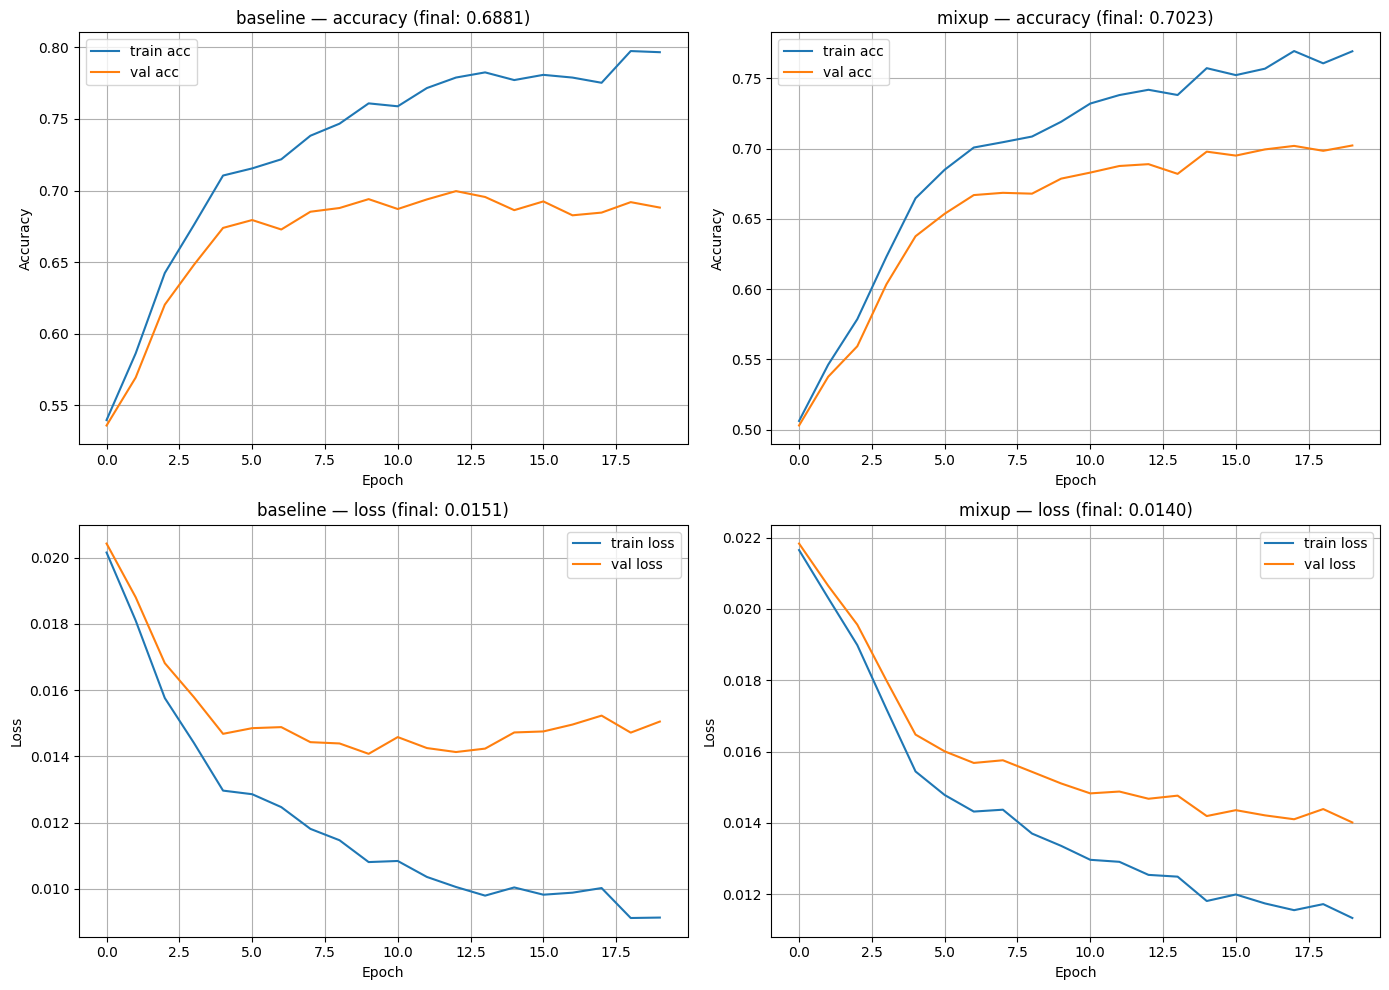


PODSUMOWANIE:
  baseline   acc = 0.6881  loss = 0.0151
  mixup      acc = 0.7023  loss = 0.0140  (+0.0142 acc, -0.0010 loss vs baseline)


In [14]:
histories_mixup = {}
results_mixup = {}

histories_mixup["baseline"] = histories["baseline"]
results_mixup["baseline"] = results["baseline"]

print(f"\n{'='*50}\nEksperyment: mixup\n{'='*50}")
torch.manual_seed(SEED)

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=to_tensor, download=True)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, pin_memory=True)

model = ThreeLayerCNN(channels=CHANNELS, labels=10)
optimiser = optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()

train_accs, val_accs, train_losses, val_losses = [], [], [], []

for epoch in tqdm(range(EPOCHS), desc="mixup", leave=False):
    model.train()
    for X_batch, y_batch in train_dl:
        X_mixed, y_mixed = mixup_batch(X_batch, y_batch)
        y_pred = model(X_mixed)
        loss = soft_cross_entropy(y_pred, y_mixed)
        loss.backward()
        optimiser.step()
        optimiser.zero_grad()

    model.eval()
    with torch.no_grad():
        train_loss, train_acc = validate(model, loss_fn, train_dl)
        val_loss, val_acc     = validate(model, loss_fn, test_dl)
    train_accs.append(train_acc.item())
    val_accs.append(val_acc.item())
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

histories_mixup["mixup"] = (train_accs, val_accs, train_losses, val_losses)
results_mixup["mixup"] = {"acc": val_accs[-1], "loss": val_losses[-1]}


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, name in enumerate(["baseline", "mixup"]):
    train_accs_p, val_accs_p, train_losses_p, val_losses_p = histories_mixup[name]

    ax = axes[0][col]
    ax.plot(train_accs_p, label="train acc")
    ax.plot(val_accs_p,   label="val acc")
    ax.set_title(f"{name} — accuracy (final: {val_accs_p[-1]:.4f})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)

    ax = axes[1][col]
    ax.plot(train_losses_p, label="train loss")
    ax.plot(val_losses_p,   label="val loss")
    ax.set_title(f"{name} — loss (final: {val_losses_p[-1]:.4f})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


print(f"\n{'='*50}\nPODSUMOWANIE:\n{'='*50}")
baseline_acc  = results_mixup["baseline"]["acc"]
baseline_loss = results_mixup["baseline"]["loss"]
for name, r in results_mixup.items():
    diff_acc  = r["acc"]  - baseline_acc
    diff_loss = r["loss"] - baseline_loss
    sign_acc  = "+" if diff_acc  >= 0 else ""
    sign_loss = "+" if diff_loss >= 0 else ""
    marker = "" if name == "baseline" else f"  ({sign_acc}{diff_acc:.4f} acc, {sign_loss}{diff_loss:.4f} loss vs baseline)"
    print(f"  {name:<10} acc = {r['acc']:.4f}  loss = {r['loss']:.4f}{marker}")

# Skrótowe połączenia

W kontekście sieci konwolucyjnych warto zpoznać się jeszcze z jedną istotną koncepcją: połączenia omijające warstwy, poprzez konkatenacje ich wyniku z wynikami dalszych warstw lub dodawanie ich wyniku do wyjścia dalszej warstwy (w drugim przypadku mówimy też o połączeniach *rezydualnych*). Połączenia takie są potrzebne szczególnie przy trenowaniu sieci bardzo głębokich, zawierających dziesiątki czy nawet ponad 100 warstw, czego nie będziemy w stanie realistycznie zrealizować w czasie naszych laboratoriów. Niemniej warto zapoznać się zarówno z samą ideą, jak i ich implementacją, jako że przy pracy z architekturami *state of the art* będziemy często natykać się na takie konstrukcje.

W konstrukcji sieci z połączeniamy pomijającymi warstwy i połączeniami rezydualnymi często będziemy spotykać się z powtarzalnymi *blokami* obejmującymi kilka warstw - dobrą praktyką implementacyjną jest wydzielanie takich bloków jako osobnych podklas `torch.nn.Module`. Warto też z góry zwrócić uwagę, że znane nam już `torch.nn.Sequential` nie uwzględnia połączeń innych niż sekwencyjne - czyli połączenia rezydualne i omijanie warstw nie wchodzi w grę, chyba że w obrębie wydzielonego bloku.

# Zadanie 3

Uzupełnij kod klasy SkipBlock tak, aby implementowała blok o zadanej strukturze.

Struktura SkipBlock:


*  zadana liczba `n` warstw konwolucyjnch, `channels x channels` kanałów, filtr 3x3, padding 1
*  aktywacja ReLU po każdej warstwie
*  pooling 2x pod koniec całego bloku
*  parametr `skip`: jeśli jest ustawiony na `true`, do wyjścia po ReLU należy **dodać** pierwotne wejście do warstwy konwolucyjnej, jeśli `false` mamy zwyczajną sekwencję warstw konwolucyjnych z aktywacjami

(Dla `skip=false` i `n=1` struktura sieci powinna odpowiadać ThreeLayerCNN powyżej.)

In [15]:
class SkipBlock(torch.nn.Module):
    def __init__(self, channels: int, n: int, skip: bool):
        super().__init__()
        self.skip = skip

        # n warstw konwolucyjnych channels→channels, 3x3, padding=1
        self.convs = torch.nn.ModuleList([
            torch.nn.Conv2d(channels, channels, 3, padding=1)
            for _ in range(n)
        ])
        self.relu = torch.nn.ReLU()
        self.pool = torch.nn.MaxPool2d(2)

    def forward(self, x):
        out = x
        for conv in self.convs:
            residual = out          # zapamiętujemy wejście przed conv
            out = conv(out)
            out = self.relu(out)
            if self.skip:
                out = out + residual  # dodajemy oryginalne wejście
        return self.pool(out)


class SkipBlockCNN(torch.nn.Module):
    def __init__(self, channels: int, labels: int, n: int, skip: bool):
        super().__init__()
        self.model = torch.nn.Sequential()

        # 3 kanały RGB → channels, kernel 1x1 (jak w ThreeLayerCNN)
        self.model.add_module("in_conv", torch.nn.Conv2d(3, channels, 1))

        # dwa bloki: 32x32 → 16x16 → 8x8
        self.model.add_module("skip_1", SkipBlock(channels, n, skip))
        self.model.add_module("skip_2", SkipBlock(channels, n, skip))

        self.model.add_module("flatten", torch.nn.Flatten())

        # channels * 8 * 8 bo dwa MaxPool2d(2): 32→16→8
        self.model.add_module("linear", torch.nn.Linear(channels * 8 * 8, labels))

    def forward(self, x):
        return self.model(x)

 Wyucz sieć SkipBlockCNN i porównaj jej wyniki z wcześniej uzykanymi. Porównaj wyniki w zależności od tego, czy włączone są skip connections.


Eksperyment: SkipBlockCNN_skip=False


SkipBlockCNN_skip=False:   0%|          | 0/20 [00:00<?, ?it/s]


Eksperyment: SkipBlockCNN_skip=True


SkipBlockCNN_skip=True:   0%|          | 0/20 [00:00<?, ?it/s]

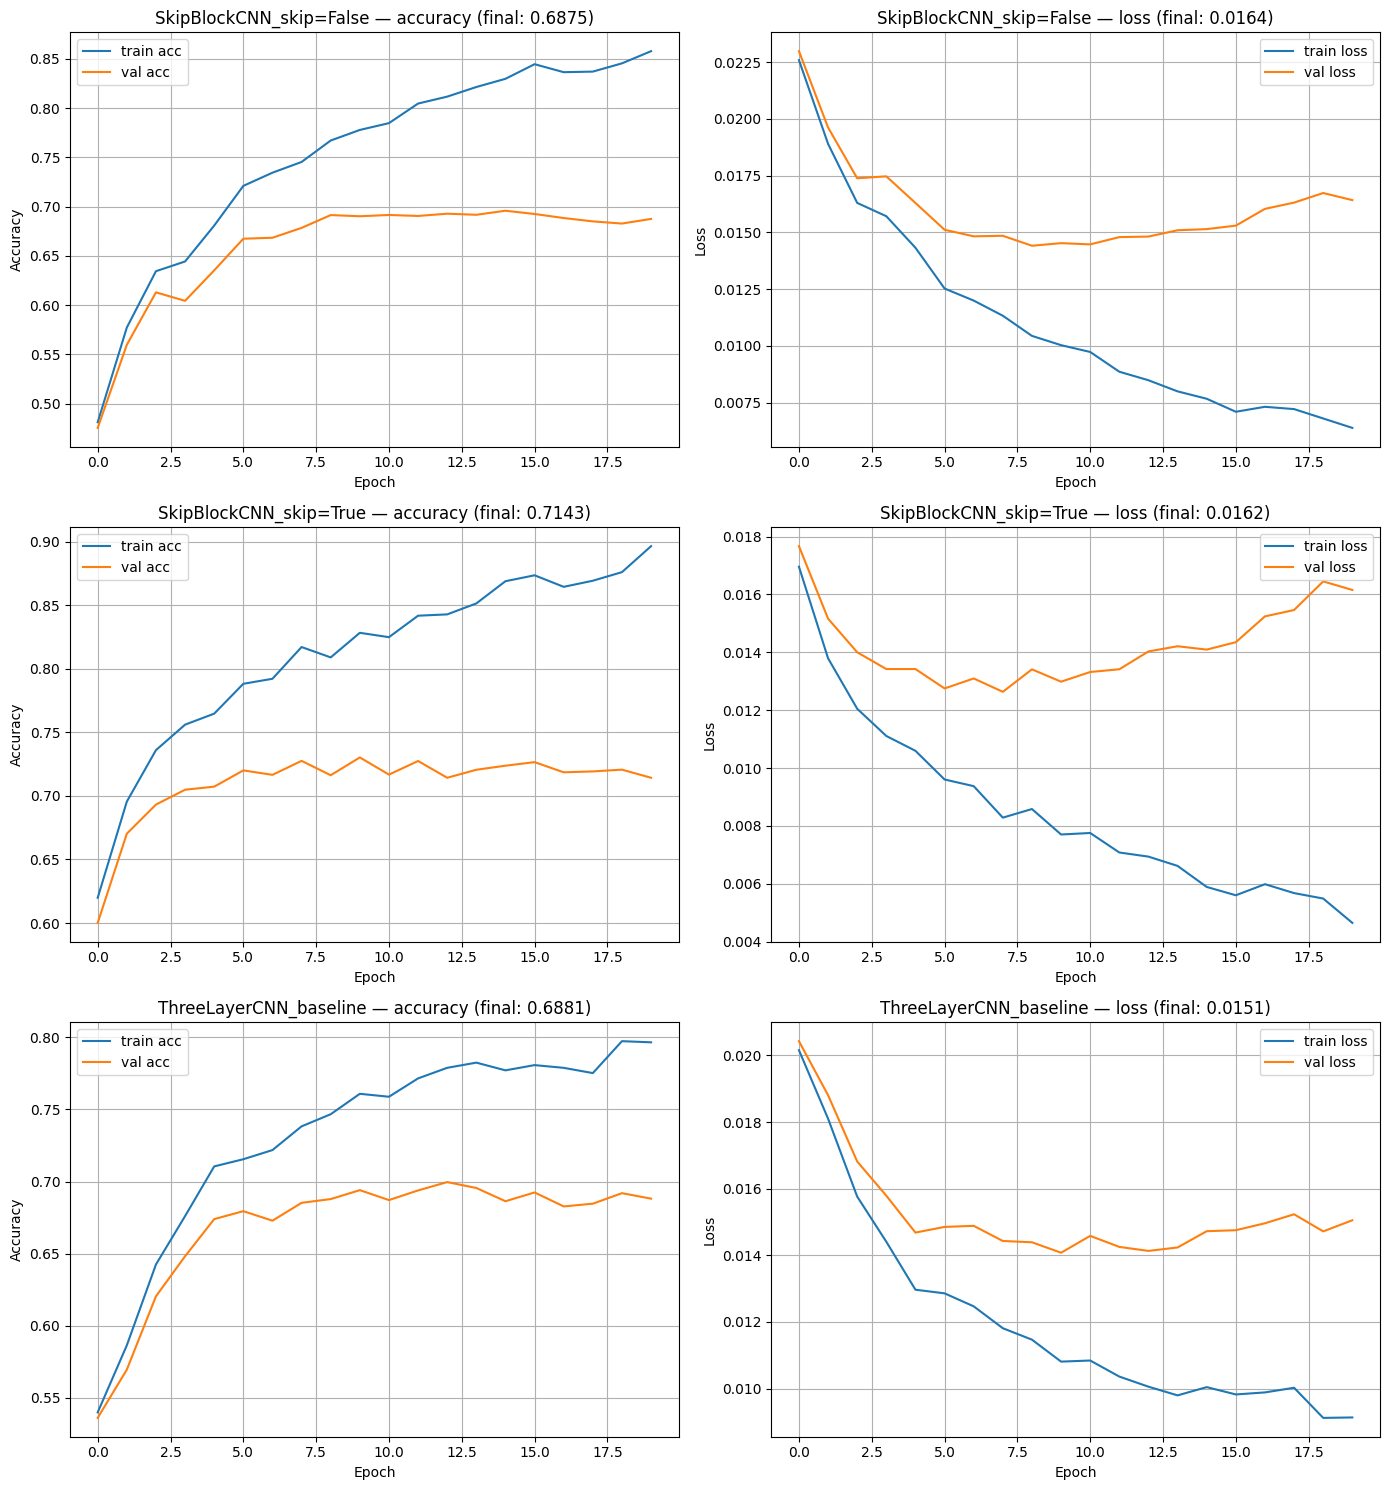


PODSUMOWANIE:
  SkipBlockCNN_skip=True              acc = 0.7143  loss = 0.0162  (+0.0262 acc, +0.0011 loss vs baseline)
  ThreeLayerCNN_baseline              acc = 0.6881  loss = 0.0151
  SkipBlockCNN_skip=False             acc = 0.6875  loss = 0.0164  (-0.0006 acc, +0.0014 loss vs baseline)


In [ ]:
results_skip = {}
histories_skip = {}

for skip in [False, True]:
    name = f"SkipBlockCNN_skip={skip}"
    print(f"\n{'='*50}\nEksperyment: {name}\n{'='*50}")
    torch.manual_seed(SEED)

    train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=to_tensor, download=True)
    train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, pin_memory=True)

    model = SkipBlockCNN(channels=32, labels=10, n=3, skip=skip)
    optimiser = optim.Adam(model.parameters())
    loss_fn = nn.CrossEntropyLoss()

    train_accs, val_accs, train_losses, val_losses = [], [], [], []

    for epoch in tqdm(range(EPOCHS), desc=name, leave=False):
        model.train()
        for X_batch, y_batch in train_dl:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimiser.step()
            optimiser.zero_grad()

        model.eval()
        with torch.no_grad():
            train_loss, train_acc = validate(model, loss_fn, train_dl)
            val_loss, val_acc     = validate(model, loss_fn, test_dl)
        train_accs.append(train_acc.item())
        val_accs.append(val_acc.item())
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

    histories_skip[name] = (train_accs, val_accs, train_losses, val_losses)
    results_skip[name] = {"acc": val_accs[-1], "loss": val_losses[-1]}

results_skip["ThreeLayerCNN_baseline"] = results["baseline"]
histories_skip["ThreeLayerCNN_baseline"] = histories["baseline"]


fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for i, name in enumerate(["SkipBlockCNN_skip=False", "SkipBlockCNN_skip=True", "ThreeLayerCNN_baseline"]):
    train_accs_p, val_accs_p, train_losses_p, val_losses_p = histories_skip[name]

    ax = axes[i][0]
    ax.plot(train_accs_p, label="train acc")
    ax.plot(val_accs_p,   label="val acc")
    ax.set_title(f"{name} — accuracy (final: {val_accs_p[-1]:.4f})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)

    ax = axes[i][1]
    ax.plot(train_losses_p, label="train loss")
    ax.plot(val_losses_p,   label="val loss")
    ax.set_title(f"{name} — loss (final: {val_losses_p[-1]:.4f})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


print(f"\n{'='*50}\nPODSUMOWANIE:\n{'='*50}")
baseline_acc  = results_skip["ThreeLayerCNN_baseline"]["acc"]
baseline_loss = results_skip["ThreeLayerCNN_baseline"]["loss"]
for name, r in sorted(results_skip.items(), key=lambda x: x[1]["acc"], reverse=True):
    diff_acc  = r["acc"]  - baseline_acc
    diff_loss = r["loss"] - baseline_loss
    sign_acc  = "+" if diff_acc  >= 0 else ""
    sign_loss = "+" if diff_loss >= 0 else ""
    marker = "" if name == "ThreeLayerCNN_baseline" else f"  ({sign_acc}{diff_acc:.4f} acc, {sign_loss}{diff_loss:.4f} loss vs baseline)"
    print(f"  {name:<35} acc = {r['acc']:.4f}  loss = {r['loss']:.4f}{marker}")